# Beat Tracker and Tempo Estimation
- Asa Picton, Connor Richardson, Dylan Baecker
- CSC475

### 1. Import libraries

In [22]:

from pathlib import Path
from joblib import Parallel, delayed
import joblib
import numpy as np
import pandas as pd
import librosa as lb
from tqdm.auto import tqdm

import scipy.signal
import matplotlib.pyplot as plt
import seaborn as sns

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, mean_absolute_error
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor



### 2. Load audio and tempo data

In [23]:
audio_path = Path("giantsteps-tempo-dataset/audio")
label_path = Path("giantsteps-tempo-dataset/annotations/tempo")

# Load tempo labels
tempo_labels = {}
for file in label_path.iterdir():
    tempo_labels[file.stem] = float(file.read_text().strip())

# Load dataset
dataset = []
for file in audio_path.iterdir():
    track_id = file.stem
    if track_id in tempo_labels:
        dataset.append((file, tempo_labels[track_id]))

print(f"Loaded {len(dataset)} audio tracks with tempo labels")


Loaded 664 audio tracks with tempo labels


In [24]:
print(len(dataset))
print(dataset[0])

664
(PosixPath('giantsteps-tempo-dataset/audio/3226172.LOFI.mp3'), 69.0)


### 3. Feature Extraction

In [25]:
def extract_features(y_audio, sr):

    features = []

    # =========================
    # 1. Onset strength
    # =========================
    onset_env = lb.onset.onset_strength(y=y_audio, sr=sr)

    if onset_env.max() > 0:
        onset_env = onset_env / onset_env.max()

    features.extend([
        np.mean(onset_env),
        np.std(onset_env),
        np.max(onset_env),
        np.median(onset_env)
    ])

    # =========================
    # 2. Librosa tempo estimate
    # =========================
    tempo_est = lb.feature.tempo(onset_envelope=onset_env, sr=sr)[0]
    features.append(tempo_est)

    # =========================
    # 3. Autocorrelation
    # =========================
    ac = lb.autocorrelate(onset_env)
    ac = ac[:len(ac)//2]

    if ac.max() > 0:
        ac = ac / ac.max()

    # Downsample to fixed size (50 dims)
    ac_ds = np.interp(
        np.linspace(0, len(ac), 50),
        np.arange(len(ac)),
        ac
    )

    features.extend(ac_ds)

    # =========================
    # 4. Tempogram full shape
    # =========================
    tg = lb.feature.tempogram(onset_envelope=onset_env, sr=sr)
    tg_mean = np.mean(tg, axis=1)

    if tg_mean.max() > 0:
        tg_mean = tg_mean / tg_mean.max()

    # Downsample to 60 dims
    tg_ds = np.interp(
        np.linspace(0, len(tg_mean), 60),
        np.arange(len(tg_mean)),
        tg_mean
    )

    features.extend(tg_ds)

    # =========================
    # 5. Tempogram peaks 
    # =========================
    tempo_freqs = lb.tempo_frequencies(tg.shape[0], sr=sr)

    peaks, props = scipy.signal.find_peaks(tg_mean, height=0.1)

    peak_bpms = np.zeros(5)
    peak_strengths = np.zeros(5)

    if len(peaks) > 0:
        order = np.argsort(props["peak_heights"])[::-1]
        peaks = peaks[order][:5]

        selected_bpms = tempo_freqs[peaks]
        selected_strengths = tg_mean[peaks]

        peak_bpms[:len(selected_bpms)] = selected_bpms
        peak_strengths[:len(selected_strengths)] = selected_strengths

    features.extend(peak_bpms)
    features.extend(peak_strengths)

    # =========================
    # 6. Rhythm regularity features
    # =========================
    # Inter-onset interval approximation
    onset_peaks = scipy.signal.find_peaks(onset_env, height=0.3)[0]

    if len(onset_peaks) > 1:
        iois = np.diff(onset_peaks)

        features.extend([
            np.mean(iois),
            np.std(iois),
            np.median(iois)
        ])
    else:
        features.extend([0, 0, 0])

    # =========================
    # 7. Spectral flux (rhythmic energy change)
    # =========================
    S = np.abs(lb.stft(y_audio))
    flux = np.sqrt(np.sum(np.diff(S, axis=1)**2, axis=0))

    if flux.max() > 0:
        flux = flux / flux.max()

    features.extend([
        np.mean(flux),
        np.std(flux),
        np.max(flux)
    ])

    return np.array(features)

In [26]:
def process_track(path, bpm):
    y_audio, sr = lb.load(path, duration=30)
    features = extract_features(y_audio, sr)

    return features, bpm


In [27]:
CACHE_FILE = Path("features_cache.pkl")

if CACHE_FILE.exists():
    print("Loading features from cache")
    X, y = joblib.load(CACHE_FILE)
    print(f"Loaded {len(X)} cached feature vectors.")
else:
    print("Extracting features")

    results = Parallel(n_jobs=-1)(
        delayed(process_track)(path, bpm)
        for path, bpm in tqdm(dataset, desc="Tracks")
    )
    X, y = zip(*results)

    joblib.dump((X, y), CACHE_FILE)
    print(f"Extracted features for {len(X)} tracks. Saved to {CACHE_FILE}.")

Loading features from cache
Loaded 664 cached feature vectors.


In [28]:
# Convert features to numpy arrays
X = np.array(X)  
y = np.array(y) 

print(f"X shape: {X.shape}")  
print(f"y shape: {y.shape}")  

X shape: (664, 131)
y shape: (664,)


### 4. Model Training 

##### 4.1 Random Forest Regressor

In [32]:
def half_double_corrected_mae(y_true, y_pred):
    candidates = np.vstack([y_pred, y_pred*2, y_pred/2])
    errors = np.abs(candidates - y_true)

    return np.mean(np.min(errors, axis=0))


def acc1(y_true, y_pred, tol=0.04):
    return np.mean(np.abs(y_pred - y_true) <= tol * y_true)


def acc2(y_true, y_pred, tol=0.04):
    candidates = np.vstack([y_pred, y_pred*2, y_pred/2])
    errors = np.abs(candidates - y_true)

    min_errors = np.min(errors, axis=0)

    return np.mean(min_errors <= tol * y_true)



def training_loop(X, y):

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    all_mae = []
    all_acc1 = []
    all_acc2 = []

    def objective(trial, X_train, y_train):

        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),
            "max_depth": trial.suggest_int("max_depth", 5, 30),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 15),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
            "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
            "min_impurity_decrease": trial.suggest_float("min_impurity_decrease", 0.0, 0.1),
        }

        model = RandomForestRegressor(
            **params,
            random_state=42,
            n_jobs=-1
        )

        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=3,
            scoring="neg_mean_absolute_error",
            n_jobs=1
        )

        return scores.mean()

    best_model = None

    for fold, (train_idx, test_idx) in enumerate(kf.split(X)):

        print(f"\nFold {fold+1}")

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]


        study = optuna.create_study(direction="maximize")

        study.optimize(
            lambda trial: objective(trial, X_train, y_train),
            n_trials=25,
            show_progress_bar=True
        )

        best_params = study.best_params

        print(f"\nFold {fold+1} best params: {best_params}")
        print(f"Best CV score: {study.best_value:.3f}")

        model = RandomForestRegressor(
            **best_params,
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train, y_train)

        if fold == 0:  
            best_model = model

        y_pred = model.predict(X_test)

    
    
        errors = np.abs(y_pred - y_test)
        print(f"Errors > 30 BPM: {np.sum(errors > 30)} / {len(errors)}")
        print(f"Errors > 60 BPM: {np.sum(errors > 60)} / {len(errors)}")

        mae = half_double_corrected_mae(y_test, y_pred)
        acc1_score = acc1(y_test, y_pred)
        acc2_score = acc2(y_test, y_pred)

        print("\nFold Results")
        print(f"MAE (half/double corrected): {mae:.2f} BPM")
        print(f"Acc1 (±4% strict): {acc1_score:.3f}")
        print(f"Acc2 (±4% half/double): {acc2_score:.3f}")

        all_mae.append(mae)
        all_acc1.append(acc1_score)
        all_acc2.append(acc2_score)

    print("\nResults")

    print(f"MAE (half/double corrected): {np.mean(all_mae):.2f} ± {np.std(all_mae):.2f} BPM")
    print(f"Acc1 (±4% strict): {np.mean(all_acc1):.3f} ± {np.std(all_acc1):.3f}")
    print(f"Acc2 (±4% half/double): {np.mean(all_acc2):.3f} ± {np.std(all_acc2):.3f}")
    return best_model


rf_model = training_loop(X, y)


Fold 1


Best trial: 16. Best value: -16.6685: 100%|██████████| 25/25 [01:44<00:00,  4.18s/it]



Fold 1 best params: {'n_estimators': 350, 'max_depth': 17, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': None, 'bootstrap': True, 'min_impurity_decrease': 0.017581180536071182}
Best CV score: -16.668
Errors > 30 BPM: 38 / 133
Errors > 60 BPM: 8 / 133

Fold Results
MAE (half/double corrected): 12.11 BPM
Acc1 (±4% strict): 0.429
Acc2 (±4% half/double): 0.451

Fold 2


Best trial: 22. Best value: -17.5047: 100%|██████████| 25/25 [02:04<00:00,  4.98s/it]



Fold 2 best params: {'n_estimators': 450, 'max_depth': 11, 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': None, 'bootstrap': True, 'min_impurity_decrease': 0.04093322755011641}
Best CV score: -17.505
Errors > 30 BPM: 31 / 133
Errors > 60 BPM: 7 / 133

Fold Results
MAE (half/double corrected): 12.02 BPM
Acc1 (±4% strict): 0.429
Acc2 (±4% half/double): 0.436

Fold 3


...


Fold 3 best params: {'n_estimators': 500, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': True, 'min_impurity_decrease': 0.05446177983662512}
Best CV score: -17.840
Errors > 30 BPM: 26 / 133
Errors > 60 BPM: 3 / 133

Fold Results
MAE (half/double corrected): 10.70 BPM
Acc1 (±4% strict): 0.496
Acc2 (±4% half/double): 0.504

Fold 4


Best trial: 22. Best value: -17.9674: 100%|██████████| 25/25 [00:34<00:00,  1.39s/it]



Fold 4 best params: {'n_estimators': 250, 'max_depth': 21, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': False, 'min_impurity_decrease': 0.08249932019484758}
Best CV score: -17.967
Errors > 30 BPM: 24 / 133
Errors > 60 BPM: 3 / 133

Fold Results
MAE (half/double corrected): 12.12 BPM
Acc1 (±4% strict): 0.383
Acc2 (±4% half/double): 0.383

Fold 5


Best trial: 12. Best value: -16.664: 100%|██████████| 25/25 [01:14<00:00,  2.97s/it]



Fold 5 best params: {'n_estimators': 350, 'max_depth': 29, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': True, 'min_impurity_decrease': 0.024888386466182764}
Best CV score: -16.664
Errors > 30 BPM: 33 / 132
Errors > 60 BPM: 6 / 132

Fold Results
MAE (half/double corrected): 13.32 BPM
Acc1 (±4% strict): 0.394
Acc2 (±4% half/double): 0.417

Results
MAE (half/double corrected): 12.06 ± 0.83 BPM
Acc1 (±4% strict): 0.426 ± 0.039
Acc2 (±4% half/double): 0.438 ± 0.040


In [34]:
def xgb_training_loop(X, y):

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    all_mae = []
    all_acc1 = []
    all_acc2 = []

    def objective(trial, X_train, y_train):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 200, 600),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "gamma": trial.suggest_float("gamma", 0, 5),
            "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10),
        }

        # Use inner cross-val instead of fitting and evaluating on the same data
        model = XGBRegressor(
            **params,
            objective="reg:squarederror",
            tree_method="hist",
            random_state=42,
            n_jobs=-1
        )

        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=3,
            scoring="neg_mean_absolute_error",
            n_jobs=1
        )

        return scores.mean() 

    best_xgb_model = None

    for fold, (train_idx, test_idx) in enumerate(kf.split(X)):

        print(f"\nFold {fold+1}")

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        study = optuna.create_study(direction="maximize")

        study.optimize(
            lambda trial: objective(trial, X_train, y_train),
            n_trials=25,
            show_progress_bar=True
        )

        best_params = study.best_params

        print(f"\nFold {fold+1} best params: {best_params}")
        print(f"Best CV score: {study.best_value:.3f}")

        model = XGBRegressor(
            **best_params,
            objective="reg:squarederror",
            tree_method="hist",
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train, y_train)

        if fold == 0:  
            best_xgb_model = model

        y_pred = model.predict(X_test)

        errors = np.abs(y_pred - y_test)
        print(f"Errors > 30 BPM: {np.sum(errors > 30)} / {len(errors)}")
        print(f"Errors > 60 BPM: {np.sum(errors > 60)} / {len(errors)}")

        mae = half_double_corrected_mae(y_test, y_pred)
        acc1_score = acc1(y_test, y_pred)
        acc2_score = acc2(y_test, y_pred)

        print("\nFold Results")
        print(f"MAE (half/double corrected): {mae:.2f} BPM")
        print(f"Acc1 (±4% strict): {acc1_score:.3f}")
        print(f"Acc2 (±4% half/double): {acc2_score:.3f}")

        all_mae.append(mae)
        all_acc1.append(acc1_score)
        all_acc2.append(acc2_score)

    print("\nResults")
    print(f"MAE (half/double corrected): {np.mean(all_mae):.2f} ± {np.std(all_mae):.2f} BPM")
    print(f"Acc1 (±4% strict): {np.mean(all_acc1):.3f} ± {np.std(all_acc1):.3f}")
    print(f"Acc2 (±4% half/double): {np.mean(all_acc2):.3f} ± {np.std(all_acc2):.3f}")
    return best_xgb_model

xgb_model = xgb_training_loop(X, y)


Fold 1


Best trial: 23. Best value: -16.4914: 100%|██████████| 25/25 [04:27<00:00, 10.68s/it]



Fold 1 best params: {'n_estimators': 480, 'max_depth': 10, 'learning_rate': 0.018908307157248862, 'subsample': 0.7220352799428768, 'colsample_bytree': 0.8194800112307907, 'gamma': 0.8505543414972425, 'reg_alpha': 0.7368495824286614, 'reg_lambda': 8.022078733891673}
Best CV score: -16.491
Errors > 30 BPM: 33 / 133
Errors > 60 BPM: 10 / 133

Fold Results
MAE (half/double corrected): 11.82 BPM
Acc1 (±4% strict): 0.444
Acc2 (±4% half/double): 0.466

Fold 2


Best trial: 22. Best value: -17.4296: 100%|██████████| 25/25 [04:08<00:00,  9.93s/it]



Fold 2 best params: {'n_estimators': 600, 'max_depth': 8, 'learning_rate': 0.013926546529931288, 'subsample': 0.6445861801222497, 'colsample_bytree': 0.756864046386782, 'gamma': 4.323019037171454, 'reg_alpha': 1.2573637709027206, 'reg_lambda': 2.2120255530835924}
Best CV score: -17.430
Errors > 30 BPM: 30 / 133
Errors > 60 BPM: 6 / 133

Fold Results
MAE (half/double corrected): 12.29 BPM
Acc1 (±4% strict): 0.391
Acc2 (±4% half/double): 0.398

Fold 3


...


Fold 3 best params: {'n_estimators': 356, 'max_depth': 10, 'learning_rate': 0.02404494369303711, 'subsample': 0.6077403872530768, 'colsample_bytree': 0.6126195303901697, 'gamma': 3.6944270393263863, 'reg_alpha': 2.465990588464107, 'reg_lambda': 3.6425142588033332}
Best CV score: -17.668
Errors > 30 BPM: 26 / 133
Errors > 60 BPM: 4 / 133

Fold Results
MAE (half/double corrected): 10.91 BPM
Acc1 (±4% strict): 0.451
Acc2 (±4% half/double): 0.459

Fold 4


Best trial: 22. Best value: -17.6404: 100%|██████████| 25/25 [03:27<00:00,  8.30s/it]



Fold 4 best params: {'n_estimators': 238, 'max_depth': 10, 'learning_rate': 0.014514961887974305, 'subsample': 0.6562277494106227, 'colsample_bytree': 0.9964561825099558, 'gamma': 4.233790243607622, 'reg_alpha': 0.007399032297068064, 'reg_lambda': 5.919917628414252}
Best CV score: -17.640
Errors > 30 BPM: 22 / 133
Errors > 60 BPM: 5 / 133

Fold Results
MAE (half/double corrected): 11.82 BPM
Acc1 (±4% strict): 0.406
Acc2 (±4% half/double): 0.414

Fold 5


Best trial: 0. Best value: -16.4149: 100%|██████████| 25/25 [02:37<00:00,  6.29s/it]



Fold 5 best params: {'n_estimators': 508, 'max_depth': 9, 'learning_rate': 0.0684605110819715, 'subsample': 0.9110929555091701, 'colsample_bytree': 0.98464078700464, 'gamma': 4.341254640062328, 'reg_alpha': 1.001523841533598, 'reg_lambda': 8.628378430792564}
Best CV score: -16.415
Errors > 30 BPM: 32 / 132
Errors > 60 BPM: 7 / 132

Fold Results
MAE (half/double corrected): 13.36 BPM
Acc1 (±4% strict): 0.364
Acc2 (±4% half/double): 0.371

Results
MAE (half/double corrected): 12.04 ± 0.80 BPM
Acc1 (±4% strict): 0.411 ± 0.033
Acc2 (±4% half/double): 0.422 ± 0.036


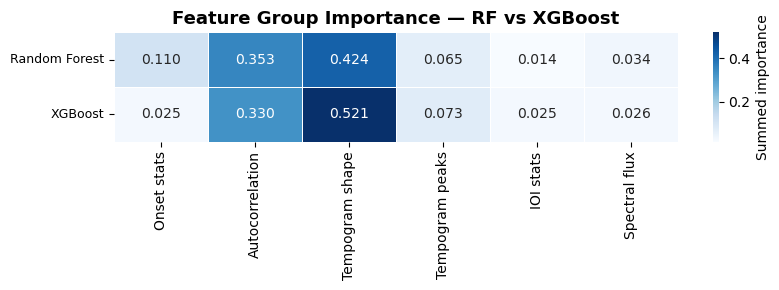

In [41]:
feature_names = (
    ['onset_mean', 'onset_std', 'onset_max', 'onset_median', 'tempo_est'] +
    [f'ac_{i}' for i in range(50)] +
    [f'tg_{i}' for i in range(60)] +
    [f'peak_bpm_{i}' for i in range(5)] +
    [f'peak_str_{i}' for i in range(5)] +
    ['ioi_mean', 'ioi_std', 'ioi_median'] +
    ['flux_mean', 'flux_std', 'flux_max']
)

rf_importance  = rf_model.feature_importances_
xgb_importance = xgb_model.feature_importances_

# Normalize each to sum to 1
rf_importance  = rf_importance  / rf_importance.sum()
xgb_importance = xgb_importance / xgb_importance.sum()

# Group into named feature groups for readability
groups = {
    'Onset stats':      slice(0, 5),
    'Autocorrelation':  slice(5, 55),
    'Tempogram shape':  slice(55, 115),
    'Tempogram peaks':  slice(115, 125),
    'IOI stats':        slice(125, 128),
    'Spectral flux':    slice(128, 131),
}

rf_grouped  = {k: rf_importance[v].sum()  for k, v in groups.items()}
xgb_grouped = {k: xgb_importance[v].sum() for k, v in groups.items()}

importance_df = pd.DataFrame({
    'Random Forest': rf_grouped,
    'XGBoost':       xgb_grouped,
}).T

fig, ax = plt.subplots(figsize=(9, 3))
sns.heatmap(
    importance_df,
    annot=True,
    fmt='.3f',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Summed importance'}
)
ax.set_title('Feature Group Importance — RF vs XGBoost', fontsize=13, fontweight='bold')
ax.set_ylabel('')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.subplots_adjust(left=0.2)
plt.savefig('feature_importance.png', dpi=150)
plt.show()